AHLI KUMPULAN:

1. WAN AINNA HUMAIRAK BINTI WAN MOHAMAD - 22001687

2. WAN QISTINA DAMIA BINTI WAN MOHD AZMI - 22002355

3. IMAN SOFFEA BINTI JAMAL - 22002203

4. LAILA NAHWAH BINTI MOHD ROSTAM - 22000869

5. SITI NURSYAHIRAH BINTI ABD RAUF - 22002206

6. NORLYDIA FARNIZA BINTI MOHD NAZARULEZUAN - 22002422

###Step 1: Data Loading
Import all required libraries and data sources


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df_car = pd.read_csv('/content/drive/MyDrive/Dataset/train.csv')
print(len(df_car))
df_car.head()

Mounted at /content/drive
5847


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50


###Step 2: Data Pre-processing
Preprocess data to ensure that the data is in a suitable format for training and evaluating machine learning models.

In [ ]:
# Data cleaning to identify and handle missing values and outliers in dataset

summary_stats = df_car.describe(include='all')  # calculate summary statistics for the dataset
missing_values = df_car.isnull().sum()  # count the number of missing values in each column

print(summary_stats)
print()
print(missing_values)

         Unnamed: 0                    Name Location         Year  \
count   5847.000000                    5847     5847  5847.000000   
unique          NaN                    1804       11          NaN   
top             NaN  Mahindra XUV500 W8 2WD   Mumbai          NaN   
freq            NaN                      49      762          NaN   
mean    3013.181461                     NaN      NaN  2013.448435   
std     1736.398890                     NaN      NaN     3.194949   
min        1.000000                     NaN      NaN  1998.000000   
25%     1509.500000                     NaN      NaN  2012.000000   
50%     3015.000000                     NaN      NaN  2014.000000   
75%     4517.500000                     NaN      NaN  2016.000000   
max     6018.000000                     NaN      NaN  2019.000000   

        Kilometers_Driven Fuel_Type Transmission Owner_Type    Mileage  \
count        5.847000e+03      5847         5847       5847       5845   
unique                N

Based on the basic statistics and missing values check, here are a few observations:

1. The dataset contains 5,847 rows.
2. Columns such as Mileage, Engine and Power have units associated with their values (e.g.,"kmpl", "CC", "bhp"). We'll need to process these to extract numerical values.
3. The New_Price column has a significant number of missing values (5,032 out of 5,847), which is around 86% of the dataset. Given the high number of missing values, it might be best to drop this column.
4. Other columns have a smaller number of missing values, and we'll need to decide how to handle them.

Let's proceed with the following steps:
1. Drop the Unnamed: 0 and New_Price columns.
2. Convert Mileage, Engine, and Power to numerical values by removing the units.
3. Handle missing values for the remaining columns.
4. Visualize key relationship in the data

In [ ]:
# method to return the set containing unique units found in the input strings

def extract_units(strings):
    units = set()
    for value in strings:
        if isinstance(value, str):  # check if the value is a string
            words = value.split()
            for i in range(len(words) - 1):
                unit = words[i + 1]
                units.add(unit)
    return units


In [ ]:
# finding unique units 'Mileage', 'Engine', 'Power' collumns

mileage_units = extract_units(df_car['Mileage'])
print(f'Unique Mileage units: {mileage_units}')

mileage_units = extract_units(df_car['Engine'])
print(f'Unique Engine volume units: {mileage_units}')

mileage_units = extract_units(df_car['Power'])
print(f'Unique Power units: {mileage_units}')

Unique Mileage units: {'km/kg', 'kmpl'}
Unique Engine volume units: {'CC'}
Unique Power units: {'bhp'}


In [ ]:
# kmpl = (km/kg)/denstiy
# density of petrol = 0.740 (avg)
# density of diesel = 0.832 (avg)

# defining conditions
condition = df_car['Mileage'].str.contains('km/kg', na=False)

# applying condition 1
for index, row in df_car[condition].iterrows():
    if row['Fuel_Type'] == 'Diesel':
        # Strip away 'km/kg' and convert to float for petrol
        converted_value = float(row['Mileage'].replace(' km/kg', '')) / 0.740  # Replace 0.8 with your specific conversion factor
        df_car.at[index, 'Mileage'] = converted_value

    if row['Fuel_Type'] == 'Petrol':
        # Strip away 'km/kg' and convert to float for petrol
        converted_value = float(row['Mileage'].replace(' km/kg', '')) / 0.832  # Replace 0.8 with your specific conversion factor
        df_car.at[index, 'Mileage'] = converted_value

# now mileage values is standardize and suitable for analysis


In [ ]:
# removing columns 'Unnamed' and 'New_Price'
df_car = df_car.drop('Unnamed: 0', axis=1)
df_car = df_car.drop('New_Price', axis=1)

# converting Mileage, Engine, and Power to Numeric
df_car['Mileage'] = df_car['Mileage'].str.split().str[0].astype(float)
df_car['Engine'] = df_car['Engine'].str.split().str[0].astype(float)
df_car['Power'] = df_car['Power'].str.replace('null bhp', 'NaN').str.split().str[0].astype(float)

# filling missing values with medians
df_car['Mileage'].fillna(df_car['Mileage'].median(), inplace=True)
df_car['Engine'].fillna(df_car['Engine'].median(), inplace=True)
df_car['Power'].fillna(df_car['Power'].median(), inplace=True)
df_car['Seats'].fillna(df_car['Seats'].median(), inplace=True)

df_car.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
1,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.19,1199.0,88.70,5.0,4.50
2,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
3,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74
4,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08,1461.0,63.10,5.0,3.50


In [ ]:
df_car.isna().sum()

Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

The data has been cleaned and the columns have been transformed to numerical values where necessary.

Now, let's visualize some key relationships in the data to understand patterns and distributions:

1. Distribution of the target variable (Price).
2. Price vs. Year of manufacture.
3. Price vs. Kilometers driven.
4. Distribution of cars based on fuel type, transmission, and owner type.
5. Price vs. Engine capacity and power

Let's start with the distribution of the Price column.

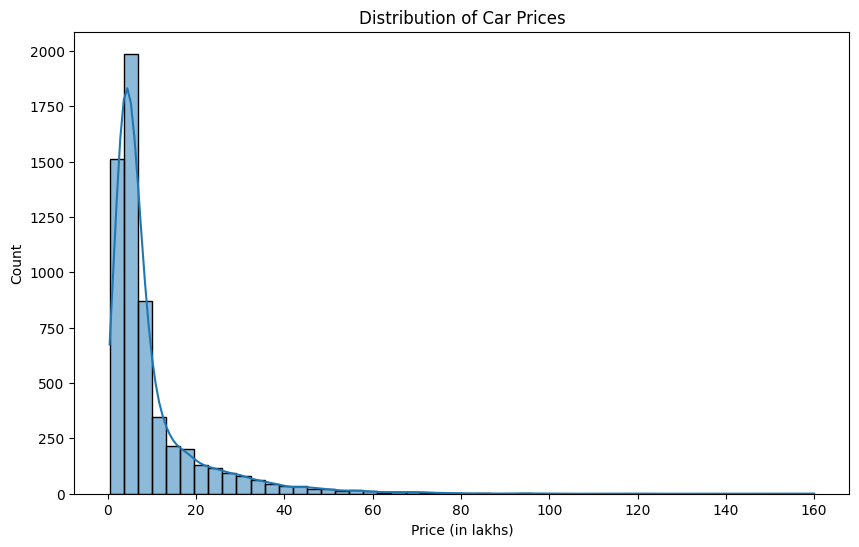

In [ ]:
# Data visulization

plt.figure(figsize=(10, 6))
sns.histplot(df_car['Price'], bins=50, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price (in lakhs)')
plt.ylabel('Count')
plt.show()

The distribution of car prices is right-skewed, which means that most of the cars in the dataset are priced on the lower end, with fewer cars having a very high price.

Next, let's visualize the relationship between the year of manufacture (Year) and the price (Price)

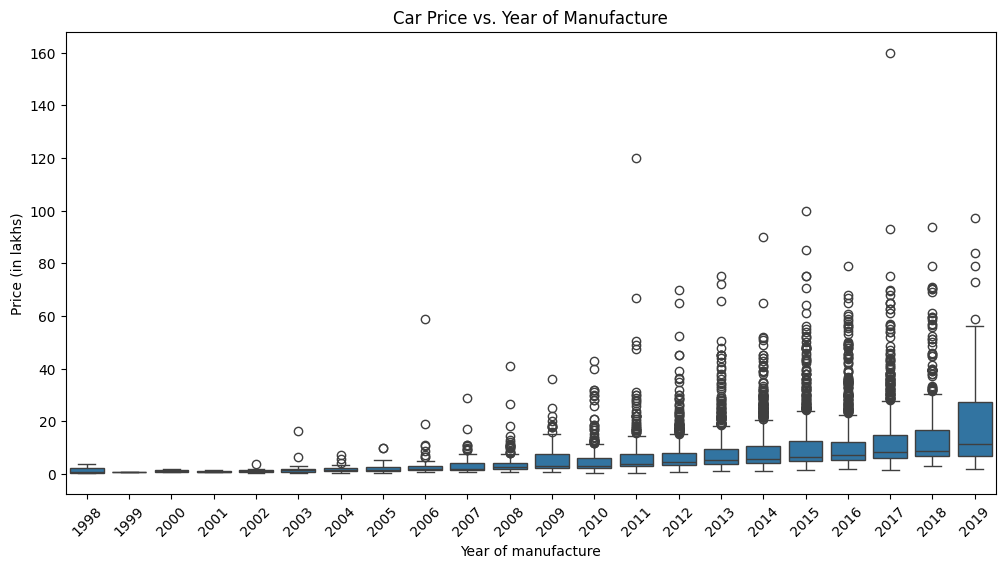

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_car['Year'], y=df_car['Price'])
plt.title('Car Price vs. Year of Manufacture')
plt.xlabel('Year of manufacture')
plt.ylabel('Price (in lakhs)')
plt.xticks(rotation=45)
plt.show()

From the boxplot, we can observe the following:


*   Newer cars (manufactured in more recent years) tend to have a higher median price compared to older cars, which is expected due to depreciation.
*   There are some outliers in earlier years, indicating that some older cars have high resale values. These could be luxury or vintage cars.

Next, let's visualize the relationship between the distance driven (Kilometers_Driven) and the price (Price)



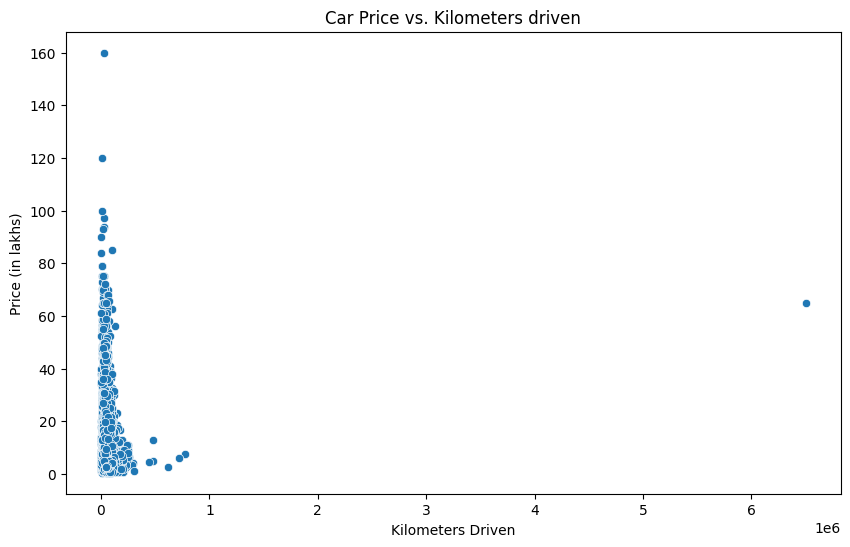

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df_car['Kilometers_Driven'], y=df_car['Price'])
plt.title('Car Price vs. Kilometers driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price (in lakhs)')
plt.show()

From the scatter plot, we observe:



*   Most cars have driven less than 1 million kilometers
*   There are a few cars with exceptionally high kilometers driven, which could be outliers.
* Generally, cars with fewer kilometers driven seem to have a higher price, which makes sense since cars with less usage usually have a higher resale value.

Let's now look at the distribution of cars based on fuel type, transmission, and owner type.



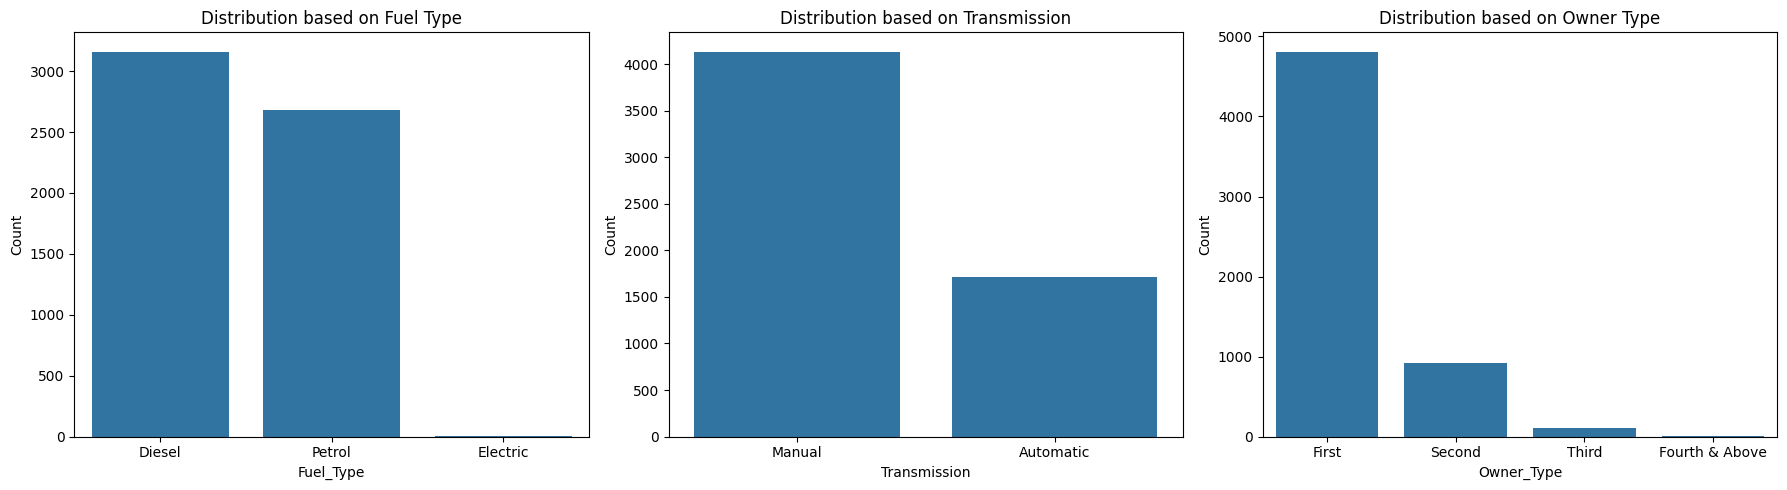

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

sns.countplot(data=df_car, x='Fuel_Type', ax=axes[0])
axes[0].set_title('Distribution based on Fuel Type')
axes[0].set_ylabel('Count')

sns.countplot(data=df_car, x='Transmission', ax=axes[1])
axes[1].set_title('Distribution based on Transmission')
axes[1].set_ylabel('Count')

sns.countplot(data=df_car, x='Owner_Type', ax=axes[2], order=df_car['Owner_Type'].value_counts().index)
axes[2].set_title('Distribution based on Owner Type')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

From the count plots:



*   Fuel Type: Diesel cars dominate the dataset, followed closely by petrol cars. There are very few cars that run on Electric.
*   Transmission: Manual transmission cars are more common in this dataset than automatic transmission cars.
* Owner Type: Most cars are being sold by their first owners, followed by second owners. There are fewer cars being sold by third or fourth & above owners.

Lastly, let's look at how car prices vary with engine capacity (Engine) and power (Power)



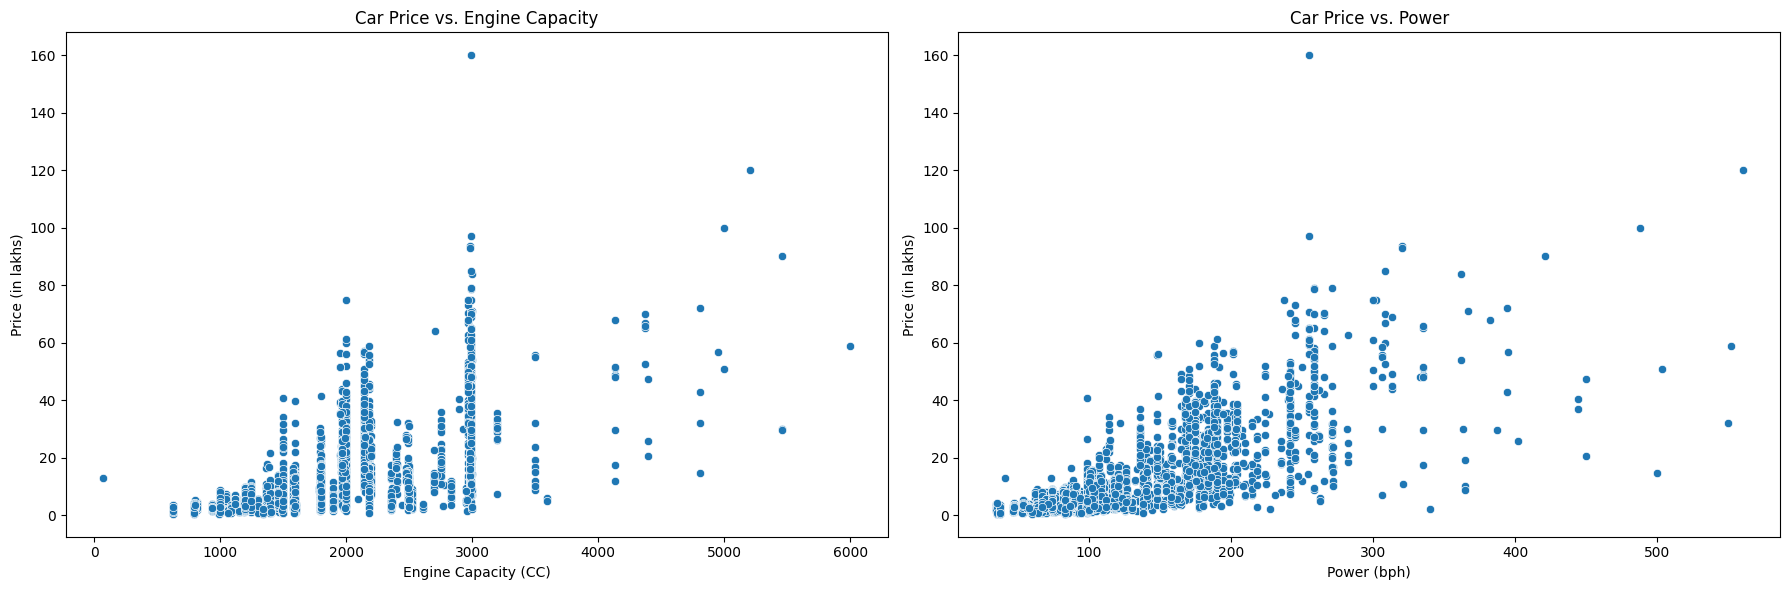

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

sns.scatterplot(data=df_car, x ='Engine', y='Price', ax=axes[0])
axes[0].set_title('Car Price vs. Engine Capacity')
axes[0].set_xlabel('Engine Capacity (CC)')
axes[0].set_ylabel('Price (in lakhs)')

sns.scatterplot(data=df_car, x ='Power', y='Price', ax=axes[1])
axes[1].set_title('Car Price vs. Power')
axes[1].set_xlabel('Power (bph)')
axes[1].set_ylabel('Price (in lakhs)')

plt.tight_layout()
plt.show()

From the scatter plots:



*   Car Price vs. Engine Capacity: There's a general trend where cars with a larger engine capacity tend to have a higher price. However, there's a wide spread, indicating that engine capacity alone isn't the only determinant of price.
*   Car Price vs. Power: Similarly, cars with higher power (in bhp) tend to have a higher price. Again, while ther's a general trend, there's variability indicating other factors at play.

With this understanding of the data, we can now move on to building a machine learning model to predict car prices. Before that, we'll need to preprocess our data further: encoding categorical variables, splitting the data into training and test sets, and scaling numerical features.



###Step 3: Data Transformation

####1. Encoding Categorical Variables


In [ ]:
df_car.head()
# One-hot encoding of categorical variables
df_car = pd.get_dummies(df_car, columns=['Location', 'Fuel_Type', 'Transmission', 'Owner_Type'], drop_first=True)

df_car.head()

#'Location', 'Fuel_Type', 'Transmission', 'Owner_Type' were one-hot encoded,
# creating binary columns for each category and dropping the first

,Name,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Location_Bangalore,Location_Chennai,...,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune,Fuel_Type_Electric,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,Hyundai Creta 1.6 CRDi SX Option,2015,41000,19.67,1582.0,126.20,5.0,12.50,0,0,...,0,0,0,1,0,0,1,0,0,0
1,Honda Jazz V,2011,46000,18.19,1199.0,88.70,5.0,4.50,0,1,...,0,0,0,0,0,1,1,0,0,0
2,Maruti Ertiga VDI,2012,87000,20.77,1248.0,88.76,7.0,6.00,0,1,...,0,0,0,0,0,0,1,0,0,0
3,Audi A4 New 2.0 TDI Multitronic,2013,40670,15.20,1968.0,140.80,5.0,17.74,0,0,...,0,0,0,0,0,0,0,0,1,0
4,Nissan Micra Diesel XV,2013,86999,23.08,1461.0,63.10,5.0,3.50,0,0,...,0,0,0,0,0,0,1,0,0,0


#### 2. Splitting the Data

Before training the model, we need to split our data into a training set and a test set. The training set will be used to train the model, and the test set will be used to evaluate its performance. We'll use 80% of the data for training and 20% for testing.

In [ ]:
# Select numeric columns for normalization
numeric_columns = ['Power', 'Engine']

# Create a subset of your DataFrame with only the numeric columns
numeric_data = df_car[numeric_columns]

# Initialize StandardScaler
scaler = StandardScaler()

# Perform standard normalization on the selected numeric columns
scaled_data = scaler.fit_transform(numeric_data)

# Update the original DataFrame with the scaled values
df_car[numeric_columns] = scaled_data


In [ ]:
features = ['Power', 'Engine']
target = 'Price'

# Separating features and target variable
X = df_car[features]
y = df_car[target]

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

####3. Scaling the Numerical Features

To ensure that our regression model performs well, we should scale the numerical features so that they have a mean of 0 and a standard deviation of 1.

In [ ]:
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the first 10 rows of the scaled training and test data
print("Scaled Training Data:")
print(X_train_scaled[:10])
print("\nScaled Test Data:")
print(X_test_scaled[:10])


Scaled Training Data:
[[ 1.89894462  1.460451  ]
 [ 0.49229714  0.92498523]
 [-0.37044664 -0.22677133]
 [-0.76430794  0.28343662]
 [ 0.49229714  0.92498523]
 [ 0.11719115  0.92498523]
 [ 1.01031852  0.86436646]
 [-0.57487941 -0.72856001]
 [-0.25791484 -1.06364707]
 [ 0.06655184 -0.22340362]]

Scaled Test Data:
[[-1.13378734 -1.39873414]
 [-0.63302084 -0.72856001]
 [ 0.82614148  0.28343662]
 [-0.57487941 -0.72856001]
 [ 0.14157304 -0.06512129]
 [ 1.08308908  1.89488549]
 [-0.87608952 -1.06364707]
 [ 2.39408453  2.25186267]
 [-0.47360079 -0.64268342]
 [-0.28417226 -0.22171977]]


####4. Applying the Z-score normalization

In [ ]:
# Applying Z-score normalization (optional)
mean_train = X_train.mean()
std_train = X_train.std()

# Z-score normalization for the training set
X_train_z_score = (X_train - mean_train) / std_train

# Use the mean and standard deviation from the training set for normalization of the test set
X_test_z_score = (X_test - mean_train) / std_train

# Display the first 10 rows of the Z-score normalized training and test data
print("Z-score Normalized Training Data:")
print(X_train_z_score[:10])
print("\nZ-score Normalized Test Data:")
print(X_test_z_score[:10])

Z-score Normalized Training Data:
         Power    Engine
113   1.898742  1.460295
4959  0.492245  0.924886
2008 -0.370407 -0.226747
4762 -0.764226  0.283406
3026  0.492245  0.924886
1183  0.117179  0.924886
2795  1.010211  0.864274
1657 -0.574818 -0.728482
3955 -0.257887 -1.063533
3116  0.066545 -0.223380

Z-score Normalized Test Data:
         Power    Engine
5110 -1.133666 -1.398585
3309 -0.632953 -0.728482
4233  0.826053  0.283406
5527 -0.574818 -0.728482
681   0.141558 -0.065114
5387  1.082973  1.894683
1611 -0.875996 -1.063533
2998  2.393829  2.251622
239  -0.473550 -0.642615
783  -0.284142 -0.221696


After that, we can do a visualization for the Z-score normalization to visual the data before and after normalization

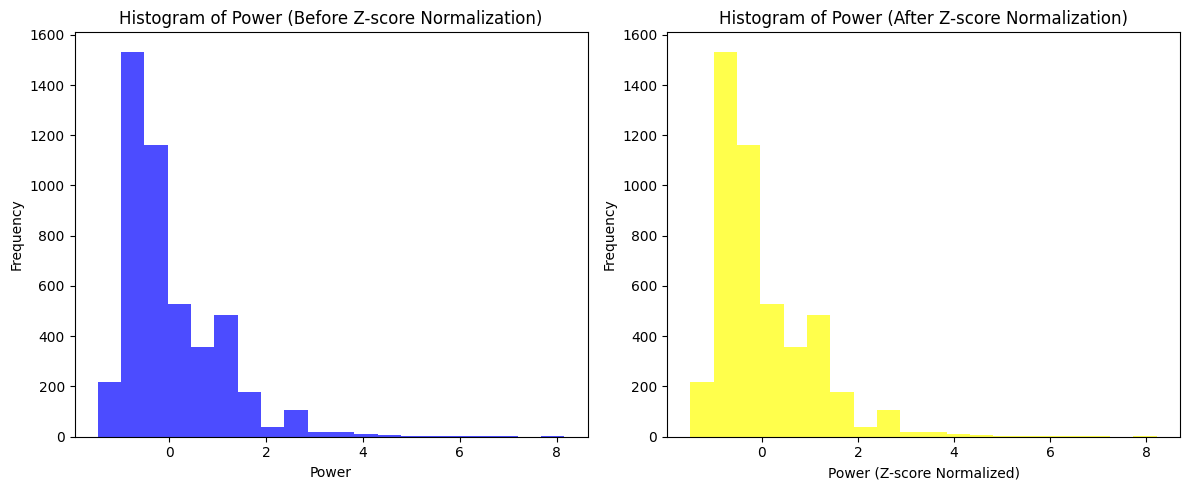

In [ ]:
import matplotlib.pyplot as plt

# Assume X_train_z_score and X_test_z_score are the Z-score normalized training and test sets

# Plot histograms before and after Z-score normalization for 'Power'
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(X_train['Power'], bins=20, color='blue', alpha=0.7)
plt.title('Histogram of Power (Before Z-score Normalization)')
plt.xlabel('Power')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(X_train_z_score['Power'], bins=20, color='yellow', alpha=0.7)
plt.title('Histogram of Power (After Z-score Normalization)')
plt.xlabel('Power (Z-score Normalized)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In the code, we have plotted histograms of the 'Power' feature before and after Z-score normalization on the training set (X_train). The Z-score normalization process standardizes the dataset by bringing the mean of each feature to 0 and the standard deviation to 1.

####5. Performing MinMax Scaling

MinMax scaling scales the data to a specific range, often [0, 1].

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Assuming you have X_train and X_test as your feature matrices

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_minmax = scaler.fit_transform(X_train)
X_test_minmax = scaler.transform(X_test)

print("Minmax Training Data:")
print(X_train_minmax[:10])
print("\nMinmax Test Data:")
print(X_test_minmax[:10])

Minmax Training Data:
[[0. 0. 1. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0. 1.]]

Minmax Test Data:
[[1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 1.]]


In [ ]:
df_car.head()

,Name,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Location_Bangalore,Location_Chennai,...,Location_Kochi,Location_Kolkata,Location_Mumbai,Location_Pune,Fuel_Type_Electric,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,Hyundai Creta 1.6 CRDi SX Option,2015,41000,19.67,-0.081186,0.232428,5.0,12.50,0,0,...,0,0,0,1,0,0,1,0,0,0
1,Honda Jazz V,2011,46000,18.19,-0.719352,-0.465388,5.0,4.50,0,1,...,0,0,0,0,0,1,1,0,0,0
2,Maruti Ertiga VDI,2012,87000,20.77,-0.637706,-0.464272,7.0,6.00,0,1,...,0,0,0,0,0,0,1,0,0,0
3,Audi A4 New 2.0 TDI Multitronic,2013,40670,15.20,0.561979,0.504111,5.0,17.74,0,0,...,0,0,0,0,0,0,0,0,1,0
4,Nissan Micra Diesel XV,2013,86999,23.08,-0.282799,-0.941764,5.0,3.50,0,0,...,0,0,0,0,0,0,1,0,0,0


Now, lets continue with Model Selection:

*   Types of Learning.
*   Choosing machine learning model to predict car prices.

Since, we want to see the relationship between Price vs. Engine capacity and power.

We also want to make prediction for the price of car, we can use Supervised Learning as a types of learning and linear regression model as machine learning model.

After choosing types of learning and machine learning model we can continue with Model Training and Evaluation.

In this part we will:

*  Train prepocessed data
*  Evaluate its performance using appropriate metrics.

Prepare train and test dataset

**Algorithm 1: Linear Regression**


In [ ]:
Ir=LinearRegression()
Ir.fit(X_train,y_train)
c=Ir.intercept_
c

9.675665178289025

In [ ]:
m=Ir.coef_
m

array([ 9.06671261, -0.30374301])

Therefore, the y-intercept of train data for engine and power is 9.68 and coefficient for the 2 features is 9.0667 and -0.3037

In [ ]:
Ir.fit(X_train_scaled,y_train)

LinearRegression()

In [ ]:
y_pred=Ir.predict(X_test_scaled)
y_pred

array([-0.09552902,  4.20779297, 17.02982984, ...,  2.13205476,
       19.6826034 ,  0.56061891])

In [ ]:
y_pred_train=Ir.predict(X_train)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6218960443277873

r2 is R-Squared that show the percentage accuracy of prediction result from the model that we make. Since, the R-square is 0.6219

Therefore, Linear regression is y=9.0667x-0.3037x+9.6757.

In [ ]:
#using z_score

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

# Initialize the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_z_score, y_train)

# Predict on the test set
y_pred = lr_model.predict(X_test_z_score)

# Calculate performance metrics
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared (R2): {r2}')

Mean Absolute Error (MAE): 4.1788354255670335
Mean Squared Error (MSE): 44.12793529270393
Root Mean Squared Error (RMSE): 6.642886066515361
R-squared (R2): 0.6218960443277872


In [ ]:
#using scaled data from StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

# Initialize the model
lr_model2 = LinearRegression()

# Train the model
lr_model2.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = lr_model2.predict(X_test_scaled)

# Calculate performance metrics
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared (R2): {r2}')

Mean Absolute Error (MAE): 4.1788354255670335
Mean Squared Error (MSE): 44.127935292703924
Root Mean Squared Error (RMSE): 6.642886066515361
R-squared (R2): 0.6218960443277873


In [ ]:
#using scaled data from MinMax

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

# Initialize the model
lr_model3 = LinearRegression()

# Train the model
lr_model3.fit(X_train_minmax, y_train)

# Predict on the test set
y_pred = lr_model3.predict(X_test_minmax)

# Calculate performance metrics
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared (R2): {r2}')

Mean Absolute Error (MAE): 5.185877011655349
Mean Squared Error (MSE): 80.18968893851648
Root Mean Squared Error (RMSE): 8.954869565689748
R-squared (R2): 0.41284732700978244


As r-squared of scaled data from MinMax is lower than r-squared from standard scaler and z-score, we would not use data from this scaling method.

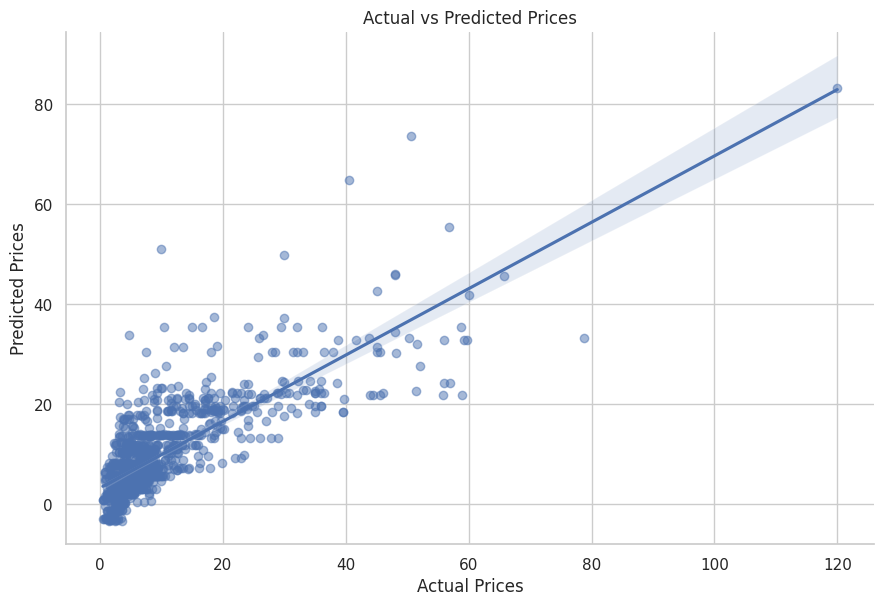

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set(style="whitegrid")

# Scatter plot with regression line using seaborn
sns.lmplot(x='Actual Prices', y='Predicted Prices', data=pd.DataFrame({'Actual Prices': y_test, 'Predicted Prices': y_pred}),
           height=6, aspect=1.5, scatter_kws={'alpha': 0.5})
plt.title("Actual vs Predicted Prices")

# Show the plot
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

# Assuming you have X_train and y_train
model = LinearRegression()
model.fit(X_train, y_train)

# Access the intercept
intercept = model.intercept_

print(f'Intercept (b0): {intercept}')


Intercept (b0): 9.675665178289025



After training the linear regression model and evaluating its performance on the test set, we observed the following:

  Performance Metrics:
  - Mean Absolute Error (MAE): 4.18
  - Mean Squared Error (MSE): 44.13
  - Root Mean Squared Error (RMSE): 6.64
  - R-squared (R2): 0.62


**Algorithm 2: Random Forest Regression**



Random forest regression is used to predict the price for all categorical values for example types of car either manual or automatic car, Types of owner either second,third or more and Types of petrol use.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Initialize the Random Forest regression model
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate performance metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf = r2_score(y_test, y_pred_rf)

# Print performance metrics
print(f'Random Forest Regression Metrics:')
print(f'Mean Absolute Error (MAE): {mae_rf}')
print(f'Mean Squared Error (MSE): {mse_rf}')
print(f'Root Mean Squared Error (RMSE): {rmse_rf}')
print(f'R-squared (R2): {r2_rf}')

Random Forest Regression Metrics:
Mean Absolute Error (MAE): 2.401609742780353
Mean Squared Error (MSE): 22.586284084015922
Root Mean Squared Error (RMSE): 4.7525029283542715
R-squared (R2): 0.8064726278386574


**Algorithm 3: Decision Tree Regression**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Instantiate the model
regressor = DecisionTreeRegressor(random_state=0, criterion='squared_error')

# Fit the model
regressor.fit(X_train, y_train)

# Make predictions with the model
y_pred_dtr = regressor.predict(X_test)

# Calculate performance metrics
mae_dtr = mean_absolute_error(y_test, y_pred_dtr)
mse_dtr = mean_squared_error(y_test, y_pred_dtr)
rmse_dtr = mean_squared_error(y_test, y_pred_dtr, squared=False)
r2_dtr = r2_score(y_test, y_pred_dtr)

# Print performance metrics
print(f'Decision Tree Regression:')
print(f'Mean Absolute Error (MAE): {mae_dtr}')
print(f'Mean Squared Error (MSE): {mse_dtr}')
print(f'Root Mean Squared Error (RMSE): {rmse_dtr}')
print(f'R-squared (R2): {r2_dtr}')


Decision Tree Regression:
Mean Absolute Error (MAE): 2.440962327928569
Mean Squared Error (MSE): 26.96181458554176
Root Mean Squared Error (RMSE): 5.192476729417452
R-squared (R2): 0.7689815152403102


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_variable = 'Price'
feature_to_predict = ['Transmission_Manual', 'Owner_Type_Fourth & Above', 'Owner_Type_Second', 'Owner_Type_Third','Fuel_Type_Electric','Fuel_Type_Petrol']

# Separating features and target variable
X = df_car[feature_to_predict]  # No need to reshape for a single feature
y = df_car[target_variable]  # Target variable

# Splitting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

cols=X_train.columns

#Scaling the dataset.
from sklearn.preprocessing import RobustScaler

scaler=RobustScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

X_train=pd.DataFrame(X_train, columns=[cols])
X_test=pd.DataFrame(X_test, columns=[cols])

#Train the model
# Create and fit the RandomForestRegressor for regression
reg_rf = RandomForestRegressor(random_state=0)
reg_rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = reg_rf.predict(X_test)

# Evaluate the model (using mean squared error as an example)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# Calculate performance metrics
mae_rf = mean_absolute_error(y_test, y_pred)
mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = mean_squared_error(y_test, y_pred)
r2_rf = r2_score(y_test, y_pred)

# Print performance metrics
print(f'Random Forest Regression Metrics:')
print(f'Mean Absolute Error (MAE): {mae_rf}')
print(f'Mean Squared Error (MSE): {mse_rf}')
print(f'Root Mean Squared Error (RMSE): {rmse_rf}')
print(f'R-squared (R2): {r2_rf}')

# Create a DataFrame for actual and predicted values
df_predicted_price = pd.DataFrame({'Actual_Price': y_test, 'Predicted_Price': y_pred})
df_predicted_price.head()


Mean Squared Error: 72.6542178902806
Random Forest Regression Metrics:
Mean Absolute Error (MAE): 4.689084767475333
Mean Squared Error (MSE): 72.6542178902806
Root Mean Squared Error (RMSE): 72.6542178902806
R-squared (R2): 0.46802240034875564


,Actual_Price,Predicted_Price
3391,4.95,6.892558
2734,13.00,25.177501
5075,5.48,4.470561
1712,2.90,6.892558
3053,4.75,6.892558


This show that this model prediction is not close to the actual values because the mean squared error is too high.

Saving Screenshot (98).png to Screenshot (98).png


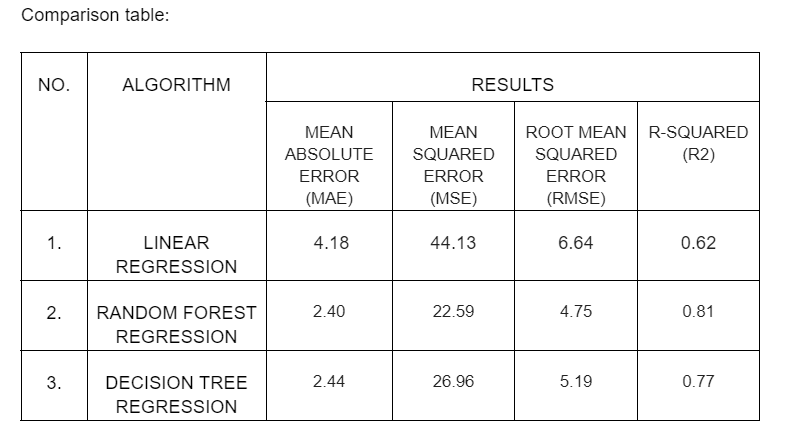

In [ ]:
from google.colab import files
from IPython.display import Image

# Upload image file
uploaded = files.upload()

# Specify the filename of the uploaded image
img_path = 'Screenshot (98).png'

# Display the image
Image(filename=img_path)

# Final comparison table

Saving a.png to a.png


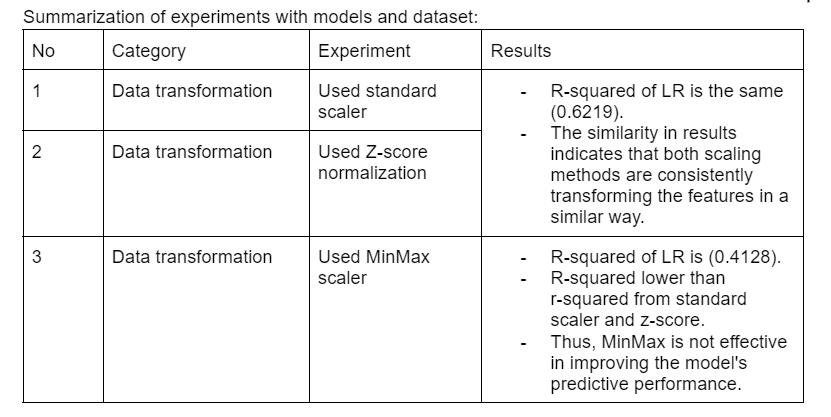

In [ ]:
from google.colab import files
from IPython.display import Image

# Upload image file
uploaded = files.upload()

# Specify the filename of the uploaded image
img_path = 'a.png'

# Display the image
Image(filename=img_path)

# Final experiment table

### **SUMMARY**


Predicting auto prices has emerged as a key use case for data-driven decision-making in the automobile sector. In this investigation, we investigate how well the random forest, linear and decision tree regression models predict automobile prices depending on different parameters.


---





**Data Overview:**

The initial examination of the dataset reveals key insights into the distribution of car prices and their relationship with features such as year of manufacture, kilometers driven, fuel type, transmission, and ownership history. Notably, the distribution of car prices is right-skewed, suggesting that a majority of cars fall into the lower price range. Additionally, newer cars tend to command higher prices, and a correlation is observed between lower kilometers driven and higher resale values. The dataset predominantly consists of diesel cars, manual transmission is more prevalent than automatic, and most cars are sold by their first owners.

**Evaluation of Linear Regression Model:**

Upon evaluating the linear regression model on the test set, the performance metrics reveal certain shortcomings.The metrics collectively indicate a notable disparity between the predicted and actual car prices, suggesting that the linear regression model does not accurately capture the underlying patterns in the data.

**Evaluation of Random Forest Regression Model:**

The improved metrics of the random forest regression model further demonstrate its robust performance. It performs better than the linear regression model in every way, demonstrating its superior capacity to forecast automobile prices. The utilization of several decision trees in the random forest approach offers a more intricate comprehension of the intricate linkages present in the dataset.


**Evaluation of Decision Tree Regression Model:**

Decision Tree Regression model performs reasonably well in predicting automobile prices based on the provided metrics. The R-squared value suggests a substantial explanation of the variance, while the MAE, MSE, and RMSE provide insights into the magnitude and nature of prediction errors.






---



**Comparison and Conclusion:**

Upon comparing the linear regression, random forest regression, and decision tree regression models, it becomes apparent that the random forest regression model outperforms both linear regression and decision tree regression in predicting car prices. The linear regression model demonstrates limitations in capturing the intricate patterns present in the dataset, leading to higher prediction errors. Similarly, the decision tree regression model, while providing reasonable performance, does not match the predictive accuracy achieved by the random forest regression model.

In summary, when it comes to precisely projecting vehicle pricing, the evaluation results highlight the random forest regression model as the preferred choice. This underscores the importance of employing advanced algorithms capable of handling the intricacies present in automobile pricing datasets. In this dynamic field, continuous research, feature engineering, and model refinement are essential to further enhance forecast accuracy and adapt to evolving market dynamics.

